<a href="https://colab.research.google.com/github/FredoToroProgrammer/novaretail-customer-correlation-analysis/blob/main/novaretail_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Cargar Dataset

In [ ]:
# Cargar dataset
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
# Vista inicial
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


## Sección 2 - Preparar datos y documentar supuestos

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos. Tras la exploración inicial con df.info() y df.describe(), no se identifican valores nulos en las variables, lo que permite avanzar directamente al análisis sin necesidad de imputaciones.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

Estas variables presentan tipos de datos adecuados (int o float) y no requieren transformaciones adicionales en esta etapa.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas como tipo object. La columna id_cliente actúa como identificador único y no será utilizada en el análisis correlacional.

In [ ]:
# Corregir el tipo de dato

# Variables binarias
df['miembro_premium'] = df['miembro_premium'].astype(int)
df['abandono'] = df['abandono'].astype(int)

# Variables categóricas
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(2), float64(5), int64(4), object(1)
memory usage: 1.2+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

`edad` — Se distribuye entre 18 y 75 años, con una media de 38 años. La distribución parece centrada en adultos, sin valores atípicos evidentes.

`nivel_ingreso` — Presenta una amplia variabilidad (desde 8,000 hasta 74,790), lo que indica diversidad socioeconómica en los clientes. La media (30,019) está cercana a la mediana, sugiriendo una distribución relativamente equilibrada.

`visitas_mes` — Oscila entre 1 y 25 visitas mensuales, con una media cercana a 10. Esto indica niveles moderados de interacción con la plataforma.

`compras_mes` — Tiene una media baja (1.2) y una mediana de 1, lo que sugiere que la mayoría de los usuarios realiza pocas compras al mes. Hay presencia de usuarios más activos (hasta 8 compras).

`gasto_publicidad_dirigida` — Varía desde 0 hasta 75.5, con una media de 20.1. Esto indica que algunos usuarios no reciben inversión publicitaria, mientras otros sí tienen un impacto significativo.

`satisfaccion` — Se mantiene dentro del rango esperado (1 a 5), con una media de 3.6. Esto sugiere una percepción general moderadamente positiva del servicio.

`miembro_premium` — La media (0.14) indica que aproximadamente el 14% de los usuarios son miembros premium, lo que representa una minoría dentro de la base de clientes.

`abandono` — Con una media de 0.15, se observa que cerca del 15% de los usuarios ha abandonado la plataforma.

`ingreso_anual` — Presenta alta variabilidad (desde 0 hasta 244.7), con una media de 36.6 y una mediana de 30.7. Esto sugiere una distribución sesgada hacia la derecha, donde pocos usuarios generan ingresos significativamente altos.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles

for col in ['miembro_premium', 'abandono']:
    print(f"{col}: {df[col].unique()}")

miembro_premium: [0 1]
abandono: [0 1]


`miembro_premium` — Presenta únicamente los valores 0 y 1, lo que confirma una correcta codificación binaria. La proporción observada previamente (~14% en 1) indica que los usuarios premium representan una minoría dentro del total de clientes.

`abandono` — También contiene exclusivamente valores 0 y 1, validando su uso como variable binaria. Con una proporción cercana al 15% de usuarios en estado de abandono, se identifica un nivel moderado de churn en la plataforma.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
for col in ['tipo_dispositivo', 'region']:
    print(f"{col}: {df[col].nunique()} valores únicos")
    print(df[col].unique())
    print("-" * 40)

tipo_dispositivo: 3 valores únicos
['móvil', 'tablet', 'escritorio']
Categories (3, object): ['móvil', 'tablet', 'escritorio']
----------------------------------------
region: 4 valores únicos
['norte', 'sur', 'este', 'oeste']
Categories (4, object): ['norte', 'sur', 'este', 'oeste']
----------------------------------------


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts(normalize=True) * 100)



Distribución de tipo_dispositivo:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

Distribución de region:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


Diagnóstico inicial de variables categóricas

-`tipo_dispositivo` — Se observa una fuerte concentración en móvil (≈65.45%), seguido por escritorio (≈24.8%) y una menor proporción en tablet (≈9.75%). Esto indica que la mayoría de los usuarios interactúa con la plataforma desde dispositivos móviles, lo que resalta la importancia de optimizar la experiencia móvil como canal principal.

-`region` — La distribución es relativamente equilibrada entre las cuatro regiones: norte (≈29.3%), oeste (≈25.4%), sur (≈24.84%) y este (≈20.46%). No hay una concentración extrema en una sola región, lo que permite realizar comparaciones geográficas sin sesgos significativos por tamaño de muestra.

En general, ambas variables presentan una estructura adecuada, con categorías bien definidas y suficiente representación en cada grupo para análisis comparativos posteriores.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

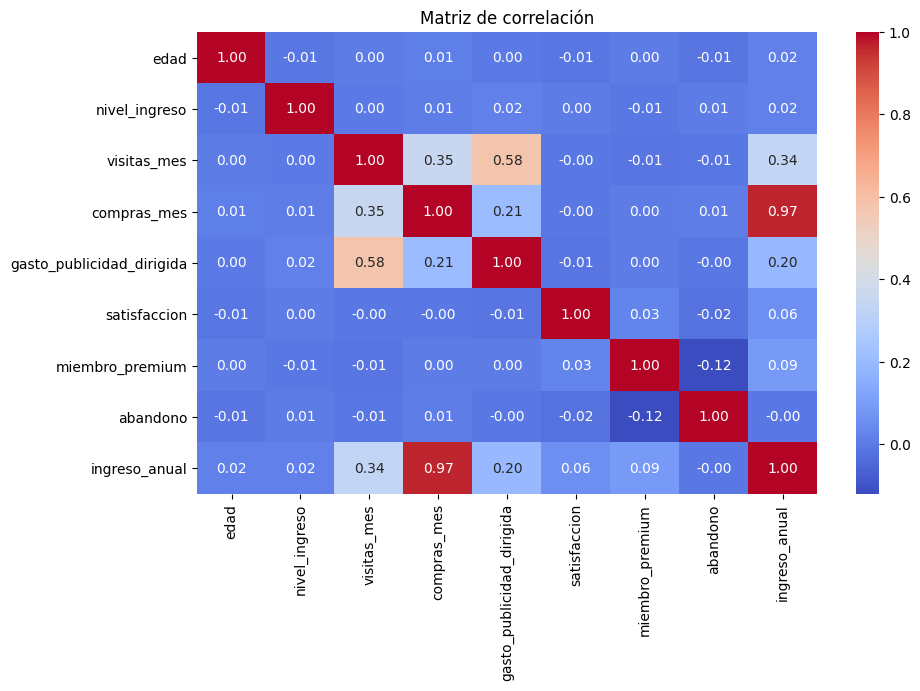

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title('Matriz de correlación')
plt.show()

Observaciones generales (Heatmap)  
- Se observa una correlación muy alta entre `compras_mes` e `ingreso_anual` (0.97), lo que indica una relación casi lineal entre ambas variables.
- Existe una correlación moderada entre `visitas_mes` y `compras_mes` (0.35), lo que sugiere que un mayor número de visitas puede traducirse en más compras, aunque no de forma directa ni perfecta.
- La variable `gasto_publicidad_dirigida` muestra una correlación moderada con `visitas_mes` (0.58), lo que indica que la inversión en publicidad está asociada con un mayor tráfico de usuarios.
- No se observan correlaciones relevantes entre variables demográficas como `edad` o `nivel_ingreso` con otras variables, lo que sugiere que el comportamiento del usuario es más importante que sus características demográficas.
- La mayoría de las variables presentan correlaciones bajas entre sí, lo que indica baja multicolinealidad fuera de las relaciones esperadas.

Observaciones respecto a `ingreso_anual`  
- ingreso_anual presenta una correlación extremadamente alta con `compras_mes` (0.97), lo que indica que el número de compras es el principal driver del ingreso generado por cliente.
- Se observa una correlación positiva moderada con `visitas_mes` (0.34), lo que sugiere que el tráfico influye en el ingreso, pero de manera indirecta.
- `gasto_publicidad_dirigida` muestra una correlación positiva débil a moderada (0.20), indicando que la publicidad puede impactar el ingreso, probablemente a través del aumento en visitas.
- `miembro_premium` tiene una correlación positiva débil (0.09), lo que sugiere que los usuarios premium tienden a generar ligeramente más ingreso, aunque no es un factor determinante.
- `satisfaccion` presenta una correlación muy baja (0.06), lo que indica que, en este dataset, la satisfacción no está fuertemente asociada con el ingreso generado.
- `abandono` no muestra una correlación significativa con el ingreso (0), lo cual puede indicar que su efecto no es lineal o que requiere otro tipo de análisis.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

El heatmap muestra una correlación extremadamente alta entre `compras_mes` e `ingreso_anual` (0.97). Debido a la magnitud de esta relación, es importante validar visualmente:

- Si la relación es realmente lineal
- Si existen valores atípicos
- Si la relación es estructural (por ejemplo, si el ingreso depende directamente del número de compras)

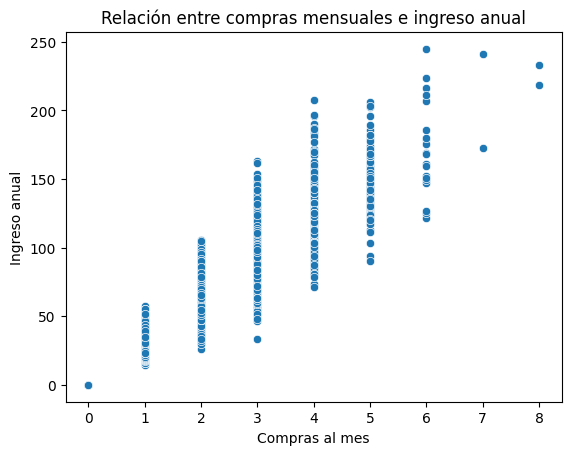

In [ ]:
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual')
plt.title('Relación entre compras mensuales e ingreso anual')
plt.xlabel('Compras al mes')
plt.ylabel('Ingreso anual')
plt.show()

### Scatterplot para pares clave

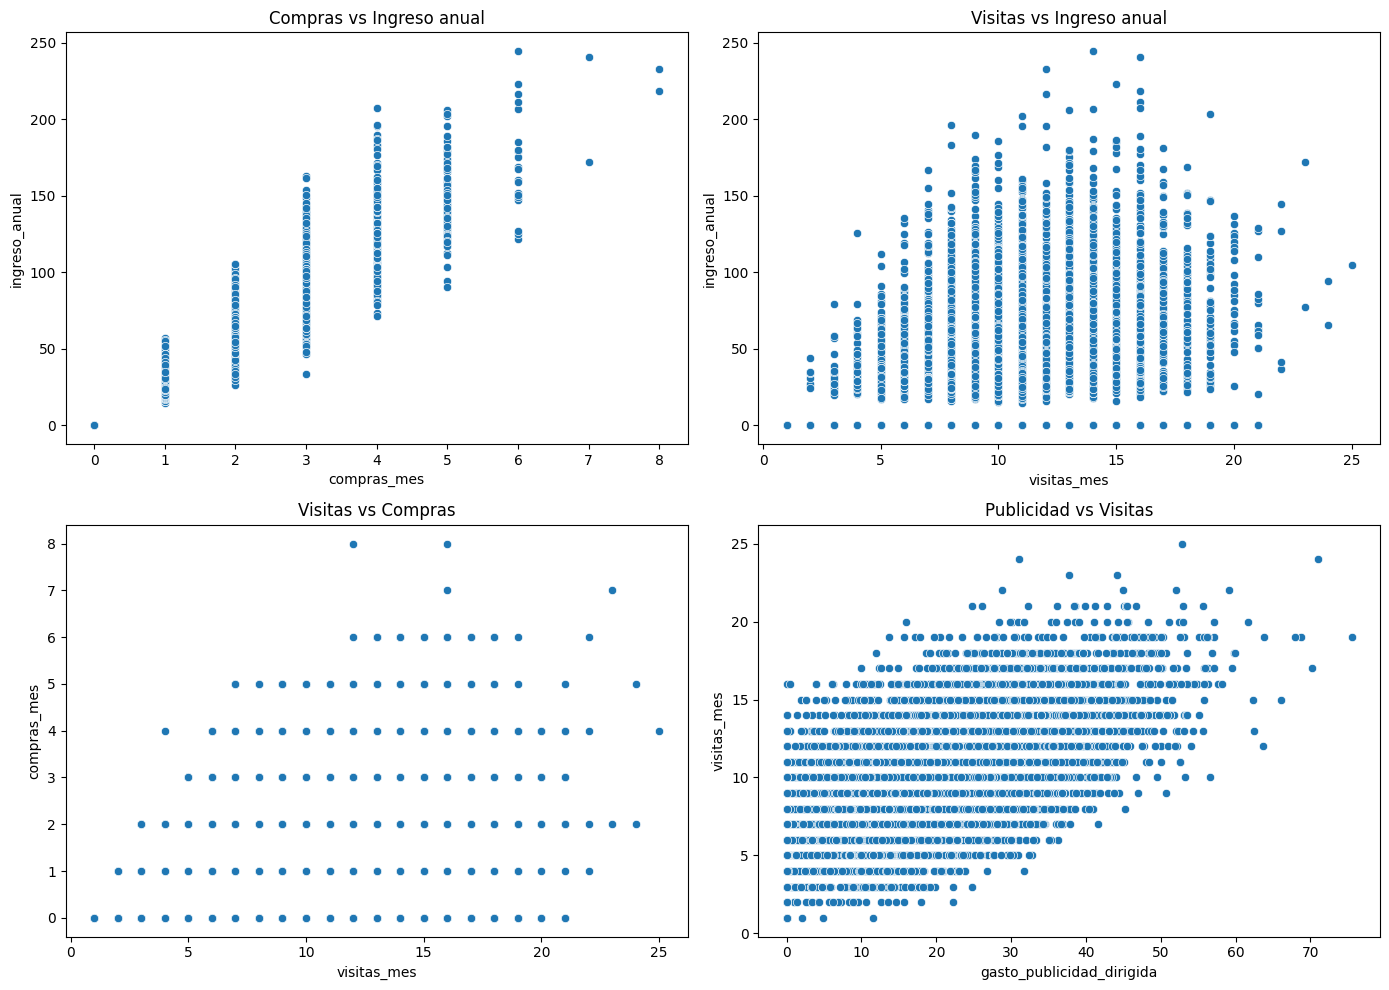

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes]
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Compras vs ingreso
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0,0])
axes[0,0].set_title('Compras vs Ingreso anual')

# 2. Visitas vs ingreso
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', ax=axes[0,1])
axes[0,1].set_title('Visitas vs Ingreso anual')

# 3. Visitas vs compras
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', ax=axes[1,0])
axes[1,0].set_title('Visitas vs Compras')

# 4. Publicidad vs visitas
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', ax=axes[1,1])
axes[1,1].set_title('Publicidad vs Visitas')

plt.tight_layout()
plt.show()

`compras_mes` vs `ingreso_anual`
- Dirección: Positiva muy fuerte. A mayor número de compras, mayor ingreso anual.
- Dispersión: Baja a media. Los puntos siguen una tendencia clara ascendente.
- Outliers: Se observan algunos clientes con ingresos muy altos en niveles altos de compras (6 a 8 compras), pero no parecen errores.
- Posible colinealidad: Alta relación con la variable objetivo, lo que confirma lo visto en el heatmap

`visitas_mes` vs `ingreso_anual`
- Dirección: Positiva moderada.
- Dispersión: Alta. Para un mismo número de visitas existen distintos niveles de ingreso.
- Outliers: Hay algunos usuarios con ingresos elevados entre 13 y 18 visitas, y otros con muchas visitas pero bajo ingreso.
- Posible colinealidad: No se observa colinealidad fuerte; la relación parece indirecta.

`visitas_mes` vs `compras_mes`
- Dirección: Positiva moderada.
- Dispersión: Media. A más visitas tienden a aumentar las compras, aunque con bastante variabilidad.
- Outliers: Algunos usuarios con muchas visitas y pocas compras, lo que podría indicar baja conversión.
- Posible colinealidad: Moderada. Sugiere que las visitas pueden influir en compras, pero no explican completamente el comportamiento.

`gasto_publicidad_dirigida` vs `visitas_mes`
- Dirección: Positiva moderada a fuerte.
- Dispersión: Media. A mayor inversión publicitaria, aumentan las visitas, aunque no de manera perfecta.
- Outliers: Existen algunos usuarios con alta inversión y visitas excepcionalmente altas.
- Posible colinealidad: Moderada. Indica que la publicidad está asociada con tráfico, pero no es el único factor.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
pearson_corr = df.corr()

pearson_corr['ingreso_anual'].sort_values(ascending=False)

ingreso_anual                1.000000
compras_mes                  0.967149
visitas_mes                  0.337147
gasto_publicidad_dirigida    0.197483
miembro_premium              0.093099
satisfaccion                 0.056171
edad                         0.017496
nivel_ingreso                0.017446
abandono                    -0.002824
Name: ingreso_anual, dtype: float64

In [ ]:
# Calcular correlación entre variables relevantes
spearman_corr = df.corr(method='spearman')

spearman_corr['ingreso_anual'].sort_values(ascending=False)

ingreso_anual                1.000000
compras_mes                  0.967482
visitas_mes                  0.320954
gasto_publicidad_dirigida    0.184999
miembro_premium              0.091883
satisfaccion                 0.060834
nivel_ingreso                0.025017
edad                         0.016097
abandono                     0.000655
Name: ingreso_anual, dtype: float64

`compras_mes` vs `ingreso_anual`
- Correlación: Positiva extremadamente fuerte.
- Magnitud: Pearson = 0.967 / Spearman = 0.967.
- Esto confirma que el número de compras es la variable más fuertemente asociada con el ingreso generado.
- La similitud entre Pearson y Spearman sugiere una relación estable, monotónica y cercana a lineal.
- Posible colinealidad: Muy alta con la variable objetivo, por lo que debe interpretarse con cautela si ingreso_anual depende directamente de compras.compras_mes vs ingreso_anual

`visitas_mes` vs `ingreso_anual`
- Correlación: Positiva moderada.
- Magnitud: Pearson = 0.337 / Spearman = 0.321.
- Indica que una mayor frecuencia de visitas tiende a asociarse con mayores ingresos, aunque con bastante variabilidad.
- La relación parece menos directa que en compras.

`gasto_publicidad_dirigida` vs `ingreso_anual`
- Correlación: Positiva débil a moderada.
- Magnitud: Pearson = 0.197 / Spearman = 0.185.
- Sugiere que la inversión publicitaria puede contribuir al ingreso, probablemente de forma indirecta al aumentar visitas o compras.

`miembro_premium` vs `ingreso_anual`
- Correlación: Positiva débil.
- Magnitud: Pearson = 0.093 / Spearman = 0.092.
- Los usuarios premium tienden a generar ligeramente más ingreso, aunque el efecto observado es reducido.

`satisfaccion` vs `ingreso_anual`
- Correlación: Positiva muy débil.
- Magnitud: Pearson = 0.056 / Spearman = 0.061.
- La satisfacción muestra una asociación limitada con el ingreso en este dataset.

`edad` y `nivel_ingreso` vs `ingreso_anual`
- Correlación: Prácticamente nula.
- Magnitud: Cercana a 0 en ambos casos.
- Las variables demográficas parecen tener poca relevancia frente al comportamiento del usuario.

`abandono` vs `ingreso_anual`
- Correlación: Nula.
- Magnitud: Pearson = -0.003 / Spearman = 0.001.
- No se observa una relación lineal o monotónica significativa con el ingreso anual.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# Premium
corr_premium, p1 = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

# Abandono
corr_abandono, p2 = pointbiserialr(df['abandono'], df['ingreso_anual'])

print("miembro_premium:", corr_premium)
print("abandono:", corr_abandono)

miembro_premium: 0.0930994396198015
abandono: -0.002823934021617148


`miembro_premium` vs `ingreso_anual`
- Relación: Positiva.
- Magnitud: Baja (r ≈ 0.093).
- Los usuarios con membresía premium tienden a generar ligeramente más ingreso anual que los usuarios no premium.
- Aunque la asociación es débil, podría reflejar mayor compromiso o frecuencia de compra entre quienes cuentan con suscripción.

`abandono` vs `ingreso_anual`
- Relación: Negativa.
- Magnitud: Muy baja / prácticamente nula (r ≈ -0.003).
- No se observa una asociación relevante entre abandono e ingreso anual en este análisis.
- Esto sugiere que el efecto del abandono no se refleja de forma lineal en la variable objetivo o requiere análisis complementarios.

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
import numpy as np
import pandas as pd
import scipy.stats as ss

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape

    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

In [ ]:
# Aplicar V de Cramér en variables relevantes
resultado = cramers_v(df['tipo_dispositivo'], df['region'])

print("V de Cramér:", round(resultado, 3))

V de Cramér: 0.012


Observaciones V de Cramér
- El coeficiente obtenido entre las variables categóricas analizadas es 0.012, un valor extremadamente cercano a cero.
- Esto indica una asociación muy débil o prácticamente inexistente entre tipo_dispositivo y region.
- En términos prácticos, la región geográfica del usuario no parece estar relacionada con el tipo de dispositivo desde el cual accede a la plataforma.
- Las categorías se comportan de forma relativamente independiente, por lo que no se identifican patrones relevantes de segmentación entre estas dos variables.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

### Hallazgo 1 —  Las compras mensuales son el factor más fuertemente asociado con el ingreso anual

- Evidencia visual:
En el heatmap y scatterplot se observa una relación positiva muy marcada entre compras_mes e ingreso_anual, con una tendencia ascendente clara y baja dispersión.

- Evidencia numérica:
Pearson = 0.967
Spearman = 0.967

- Interpretación
Los clientes que realizan más compras al mes tienden a generar significativamente más ingreso anual para la empresa. Esta es la relación más fuerte encontrada en el análisis y posiciona a la frecuencia de compra como el principal indicador asociado al valor económico del cliente.

- No podemos afirmar
No podemos concluir que aumentar artificialmente el número de compras causará directamente más ingreso sin considerar otros factores como ticket promedio, promociones, tipo de cliente o estacionalidad.

- Implicación de negocio
Priorizar estrategias orientadas a incrementar la frecuencia de compra, como programas de fidelización, campañas de recompra, recomendaciones personalizadas y automatizaciones de retención post-compra.

### Hallazgo 2 —  Las visitas mensuales tienen una relación positiva moderada con el ingreso

- Evidencia visual:
El scatterplot entre visitas_mes e ingreso_anual muestra una tendencia positiva, aunque con mayor dispersión que en compras.

- Evidencia numérica:
Pearson = 0.337
Spearman = 0.321

- Interpretación
Los usuarios que visitan más la plataforma tienden a generar mayores ingresos, pero la relación no es tan fuerte como la observada con compras. Esto sugiere que las visitas son relevantes como etapa previa de conversión.

- No podemos afirmar
No podemos afirmar que aumentar el tráfico por sí solo incrementará ingresos, ya que muchas visitas pueden no convertirse en compras.

- Implicación de negocio
Optimizar experiencia de navegación, remarketing, personalización y funnels de conversión para transformar visitas en compras efectivas.


### Hallazgo 3 — La publicidad dirigida parece influir de forma indirecta en el ingreso

- Evidencia visual:
El scatterplot entre gasto_publicidad_dirigida y visitas_mes muestra relación positiva moderada. Con ingreso, la relación es más débil.

- Evidencia numérica:
Publicidad vs ingreso anual (Pearson) = 0.197
Publicidad vs visitas (Heatmap) = 0.58

- Interpretación
La inversión publicitaria se asocia más con el aumento de visitas que con el ingreso directo, lo que sugiere un efecto indirecto dentro del proceso comercial.

- No podemos afirmar
No podemos asegurar que aumentar presupuesto publicitario siempre generará más ingresos sin medir eficiencia, segmentación o retorno de inversión.

- Implicación de negocio
Evaluar campañas por conversiones y no solo por tráfico. Optimizar targeting y medir ROI por segmento.

### Hallazgo 4 — La membresía premium muestra una asociación positiva, pero limitada

- Evidencia numérica:
Punto biserial = 0.093

- Interpretación
Los usuarios premium tienden a generar ligeramente más ingreso que los no premium, aunque la magnitud de la relación es reducida.

- No podemos afirmar
No podemos concluir que lanzar más membresías premium aumentará ingresos sin analizar uso real del beneficio, permanencia o perfil del usuario.

- Implicación de negocio
Revisar propuesta de valor premium, beneficios y segmentación para fortalecer el impacto económico del programa.

### Hallazgo 5 — Variables demográficas y categóricas tienen baja relevancia en este análisis

- Evidencia visual:
En el heatmap no se observan relaciones relevantes con edad, nivel_ingreso ni entre variables categóricas.

- Evidencia numérica:
Edad vs ingreso = 0.017
Nivel_ingreso vs ingreso = 0.017
V de Cramér = 0.012

- Interpretación
Las características demográficas y categóricas parecen explicar poco el ingreso anual frente a variables de comportamiento.

- No podemos afirmar
No podemos descartar completamente su importancia; podrían influir en combinación con otras variables o en segmentos específicos.

- Implicación de negocio
Priorizar segmentación basada en comportamiento real (visitas, compras, engagement) más que únicamente en variables demográficas.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad. Las relaciones identificadas muestran asociación entre variables, pero no permiten afirmar causa y efecto.
- Algunas variables pueden estar estructuralmente relacionadas, como compras_mes e ingreso_anual, por lo que su alta correlación debe interpretarse con cautela.
- El análisis se basa en variables disponibles en el dataset. Factores no incluidos, como promociones, ticket promedio, competencia, estacionalidad o experiencia del usuario, también podrían influir en los resultados.
- Las correlaciones lineales pueden no capturar relaciones más complejas o no lineales entre variables.
- Los resultados representan una fotografía del comportamiento durante 2024 y podrían cambiar en otros periodos.

### **Próximos pasos**

Paso 1 -Probar segmentación adicional
- Opción 1
Segmentar clientes por nivel de actividad (visitas_mes, compras_mes) para identificar perfiles de alto, medio y bajo valor.
- Opción 2
Segmentar por comportamiento de monetización: premium vs no premium, compradores frecuentes vs ocasionales.

Paso 2 — Profundizar análisis explicativo
- Opción 1
Construir modelos predictivos (regresión o árboles de decisión) para estimar qué variables explican mejor el ingreso anual.

Paso 3 — Diseñar experimentación
- Opción 1
Implementar pruebas A/B en campañas de retención, membresía premium o recomendaciones personalizadas para validar impacto real sobre compras e ingresos.